# Автоматизированная ML-система предсказания рисков строительного проекта
## Ноутбук 1: Разведочный анализ данных (EDA)

**Автор:** Перминов Артем Александрович  
**Дисциплина:** Автоматизация машинного обучения  
**Датасет:** BIM-AI Integrated Dataset

---

### Цель ноутбука
Изучить структуру данных, распределение признаков и целевой переменной, выявить закономерности и аномалии перед построением ML-пайплайна.

### Содержание
1. [Загрузка данных](#1)
2. [Общая информация о датасете](#2)
3. [Анализ целевой переменной](#3)
4. [Анализ категориальных признаков](#4)
5. [Анализ числовых признаков](#5)
6. [Корреляционный анализ](#6)
7. [Анализ дат и временных признаков](#7)
8. [Ключевые выводы](#8)

## 1. Загрузка библиотек и данных <a id='1'></a>

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Настройка визуализации
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Цветовая палитра для классов риска
RISK_COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
RISK_ORDER  = ['Low', 'Medium', 'High']

print('Библиотеки загружены')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   seaborn : {sns.__version__}')

Библиотеки загружены
   pandas  : 2.1.4
   numpy   : 1.26.4
   seaborn : 0.13.2


In [16]:
# Загрузка датасета
DATA_PATH = Path('../data/raw/bim_ai_civil_engineering_dataset.csv')

df = pd.read_csv(DATA_PATH, parse_dates=['Start_Date', 'End_Date'])

print(f'Датасет загружен: {DATA_PATH.name}')
print(f'   Строк    : {df.shape[0]:,}')
print(f'   Признаков: {df.shape[1]}')
df.head()

Датасет загружен: bim_ai_civil_engineering_dataset.csv
   Строк    : 1,000
   Признаков: 28


,Project_ID,Project_Type,Location,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,...,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level
0,PJT_1,Tunnel,Houston,2020-01-01,2021-09-26,12260784,1.505450e+07,2.793720e+06,699,813.914852,...,25202.994687,244.843310,6602,76.300184,8,6.192198,52.988330,0,95.006343,High
1,PJT_2,Dam,Houston,2020-01-02,2020-12-06,2369277,3.507054e+06,1.137777e+06,269,384.118221,...,49066.172542,263.123025,7121,63.527671,5,2.134473,50.885745,0,25.294824,Low
2,PJT_3,Building,Houston,2020-01-03,2021-12-05,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,...,48192.547163,608.985023,9956,47.099444,2,3.113728,93.905836,0,97.478830,Medium
3,PJT_4,Dam,Houston,2020-01-04,2022-04-12,24499306,2.946966e+07,4.970354e+06,809,974.565655,...,19811.151750,673.574344,3725,86.846394,5,4.070101,90.454316,1,95.098131,High
4,PJT_5,Dam,Seattle,2020-01-05,2022-02-12,1749971,2.329338e+06,5.793670e+05,354,347.990127,...,44866.565169,765.476122,4368,61.827163,6,2.759351,78.391069,0,43.624985,Low


## 2. Общая информация о датасете <a id='2'></a>

In [17]:
# Типы данных и пропуски
info = pd.DataFrame({
    'Тип':       df.dtypes,
    'Пропуски':  df.isnull().sum(),
    'Уникальных': df.nunique(),
    'Пример':    df.iloc[0]
})
print('Структура датасета:')
display(info)

Структура датасета:


,Тип,Пропуски,Уникальных,Пример
Project_ID,object,0,1000,PJT_1
Project_Type,object,0,5,Tunnel
Location,object,0,5,Houston
Start_Date,datetime64[ns],0,1000,2020-01-01 00:00:00
End_Date,datetime64[ns],0,691,2021-09-26 00:00:00
Planned_Cost,int64,0,1000,12260784
Actual_Cost,float64,0,1000,15054504.045889
Cost_Overrun,float64,0,1000,2793720.045889
Planned_Duration,int64,0,546,699
Actual_Duration,float64,0,1000,813.914852


In [18]:
# Статистика числовых признаков
print('Описательная статистика:')
display(df.describe().round(2))

Описательная статистика:


,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,Schedule_Deviation,Vibration_Level,Crack_Width,...,Air_Quality_Index,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage
count,1000,1000,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,...,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0,1000.00
mean,2021-05-14 12:00:00,2022-11-21 17:24:00,26415087.63,31541079.26,5125991.63,538.62,645.56,106.94,1.04,2.46,...,174.77,27403.79,543.40,5395.22,69.45,4.57,5.33,74.92,0.2,55.18
min,2020-01-01 00:00:00,2020-09-01 00:00:00,1045475.00,1180251.53,-4648578.92,180.00,165.28,-79.14,0.11,0.00,...,50.00,5054.16,101.20,1001.00,40.02,0.00,1.00,50.04,0.0,10.09
25%,2020-09-06 18:00:00,2022-03-01 00:00:00,14310133.00,16096546.66,581066.14,361.00,424.25,22.40,0.57,1.22,...,112.75,16153.65,311.35,3154.75,54.15,2.00,3.06,62.13,0.0,32.53
50%,2021-05-14 12:00:00,2022-11-08 00:00:00,26908602.00,31339224.46,3326817.48,535.50,635.47,84.06,1.04,2.42,...,177.00,27042.80,534.19,5371.00,69.53,5.00,5.34,74.88,0.0,55.31
75%,2022-01-19 06:00:00,2023-08-28 00:00:00,39570293.25,45327468.95,8665132.39,713.00,831.64,173.95,1.54,3.66,...,236.00,38909.34,773.81,7616.50,84.78,7.00,7.49,87.53,0.0,78.20
max,2022-09-26 00:00:00,2025-02-20 00:00:00,49968538.00,72519386.55,24012292.06,899.00,1340.35,446.35,2.00,5.00,...,299.00,49941.43,998.96,9997.00,100.00,9.00,9.97,99.98,1.0,99.95
std,NaN,NaN,14485761.88,18095958.81,5931350.17,204.53,269.38,110.39,0.55,1.43,...,72.25,13009.21,263.35,2617.17,17.36,2.88,2.56,14.61,0.4,25.82


In [19]:
# Проверка пропусков (визуально)
missing = df.isnull().sum()
if missing.sum() == 0:
    print('Пропущенных значений нет — датасет чистый!')
else:
    print('Пропуски:')
    display(missing[missing > 0])

Пропущенных значений нет — датасет чистый!


## 3. Анализ целевой переменной — Risk_Level <a id='3'></a>

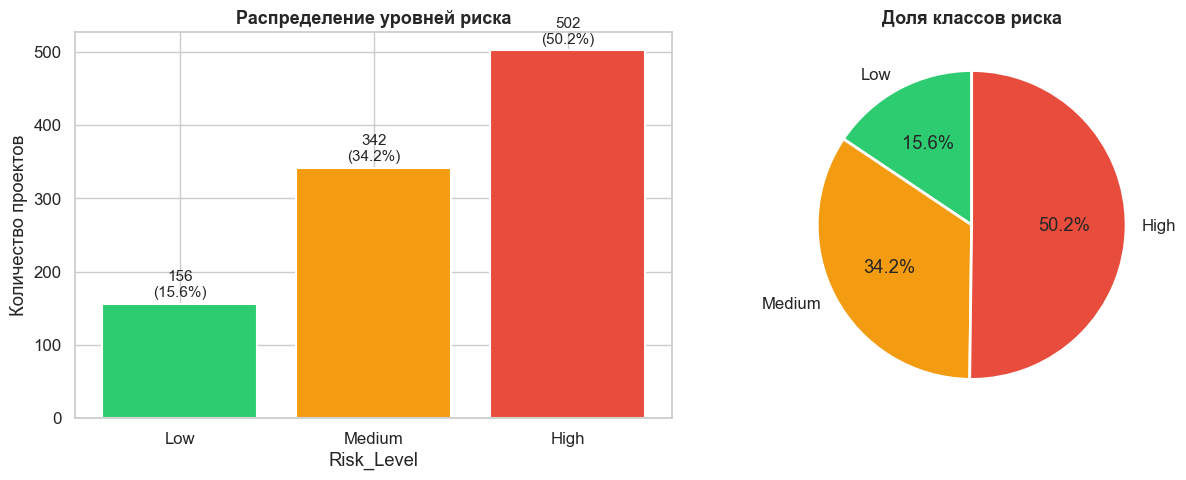


Распределение классов:
   Low   :  156 (15.6%)
   Medium:  342 (34.2%)
   High  :  502 (50.2%)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Countplot
counts = df['Risk_Level'].value_counts().reindex(RISK_ORDER)
bars = axes[0].bar(counts.index, counts.values,
                   color=[RISK_COLORS[r] for r in counts.index],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Распределение уровней риска', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk_Level')
axes[0].set_ylabel('Количество проектов')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(counts.values,
            labels=counts.index,
            colors=[RISK_COLORS[r] for r in counts.index],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Доля классов риска', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nРаспределение классов:')
for risk in RISK_ORDER:
    n = counts[risk]
    print(f'   {risk:6s}: {n:4d} ({n/len(df)*100:.1f}%)')


## 4. Анализ категориальных признаков <a id='4'></a>

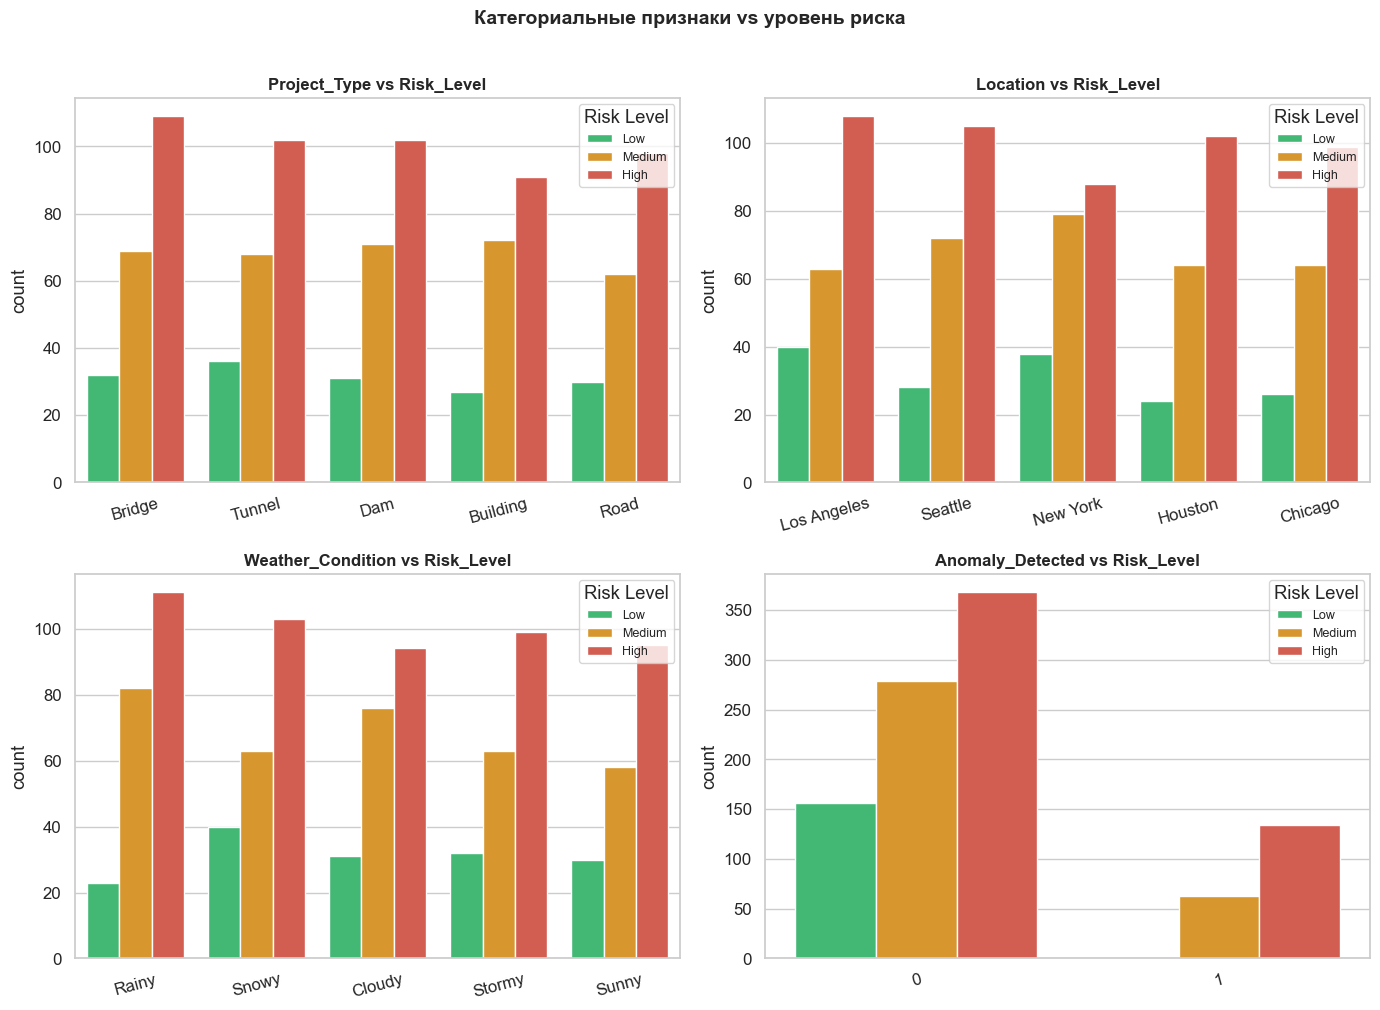

In [21]:
cat_cols = ['Project_Type', 'Location', 'Weather_Condition', 'Anomaly_Detected']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue='Risk_Level',
                  hue_order=RISK_ORDER,
                  palette=RISK_COLORS,
                  order=order, ax=ax)
    ax.set_title(f'{col} vs Risk_Level', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Risk Level', fontsize=9)

plt.suptitle('Категориальные признаки vs уровень риска', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/02_categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Анализ числовых признаков <a id='5'></a>

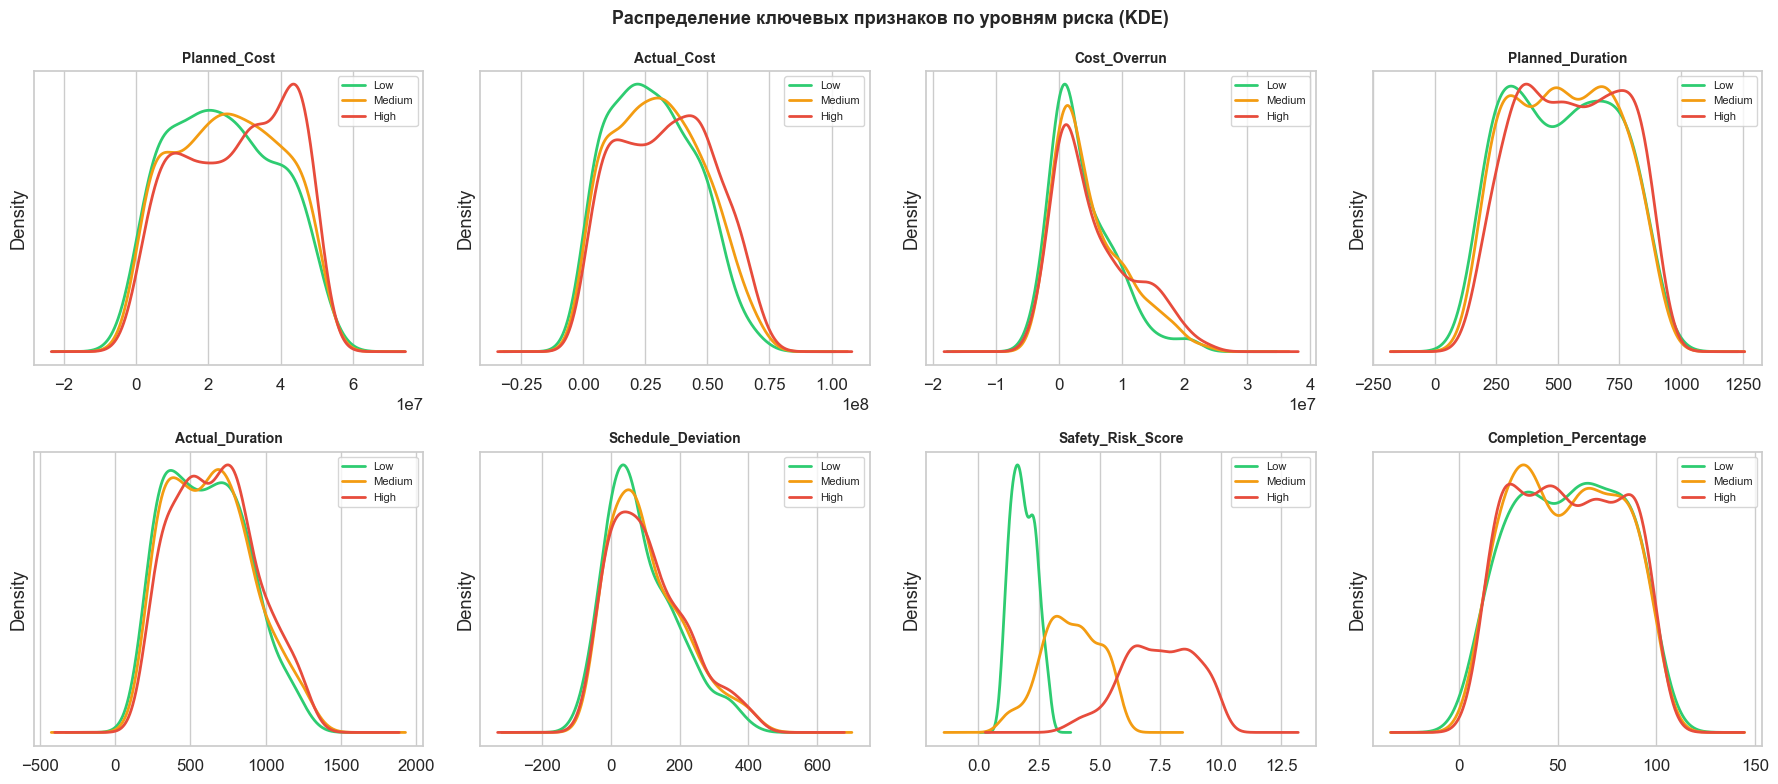

In [22]:
# Ключевые числовые признаки для анализа
key_num_cols = [
    'Planned_Cost', 'Actual_Cost', 'Cost_Overrun',
    'Planned_Duration', 'Actual_Duration', 'Schedule_Deviation',
    'Safety_Risk_Score', 'Completion_Percentage'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_num_cols):
    for risk in RISK_ORDER:
        subset = df[df['Risk_Level'] == risk][col]
        subset.plot.kde(ax=ax, label=risk, color=RISK_COLORS[risk], linewidth=2)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.set_yticks([])

plt.suptitle('Распределение ключевых признаков по уровням риска (KDE)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

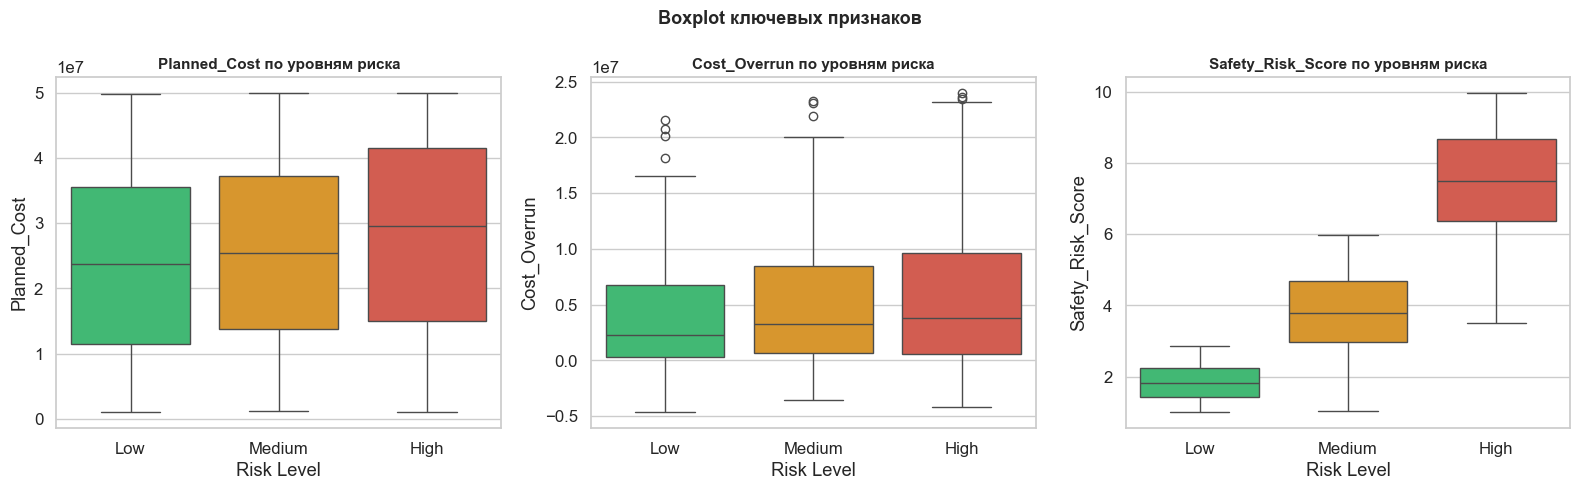

In [23]:
# Boxplot — выбросы по ключевым финансовым признакам
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Planned_Cost', 'Cost_Overrun', 'Safety_Risk_Score']):
    sns.boxplot(data=df, x='Risk_Level', y=col,
                order=RISK_ORDER,
                palette=RISK_COLORS, ax=ax)
    ax.set_title(f'{col} по уровням риска', fontsize=11, fontweight='bold')
    ax.set_xlabel('Risk Level')

plt.suptitle('Boxplot ключевых признаков', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Корреляционный анализ <a id='6'></a>

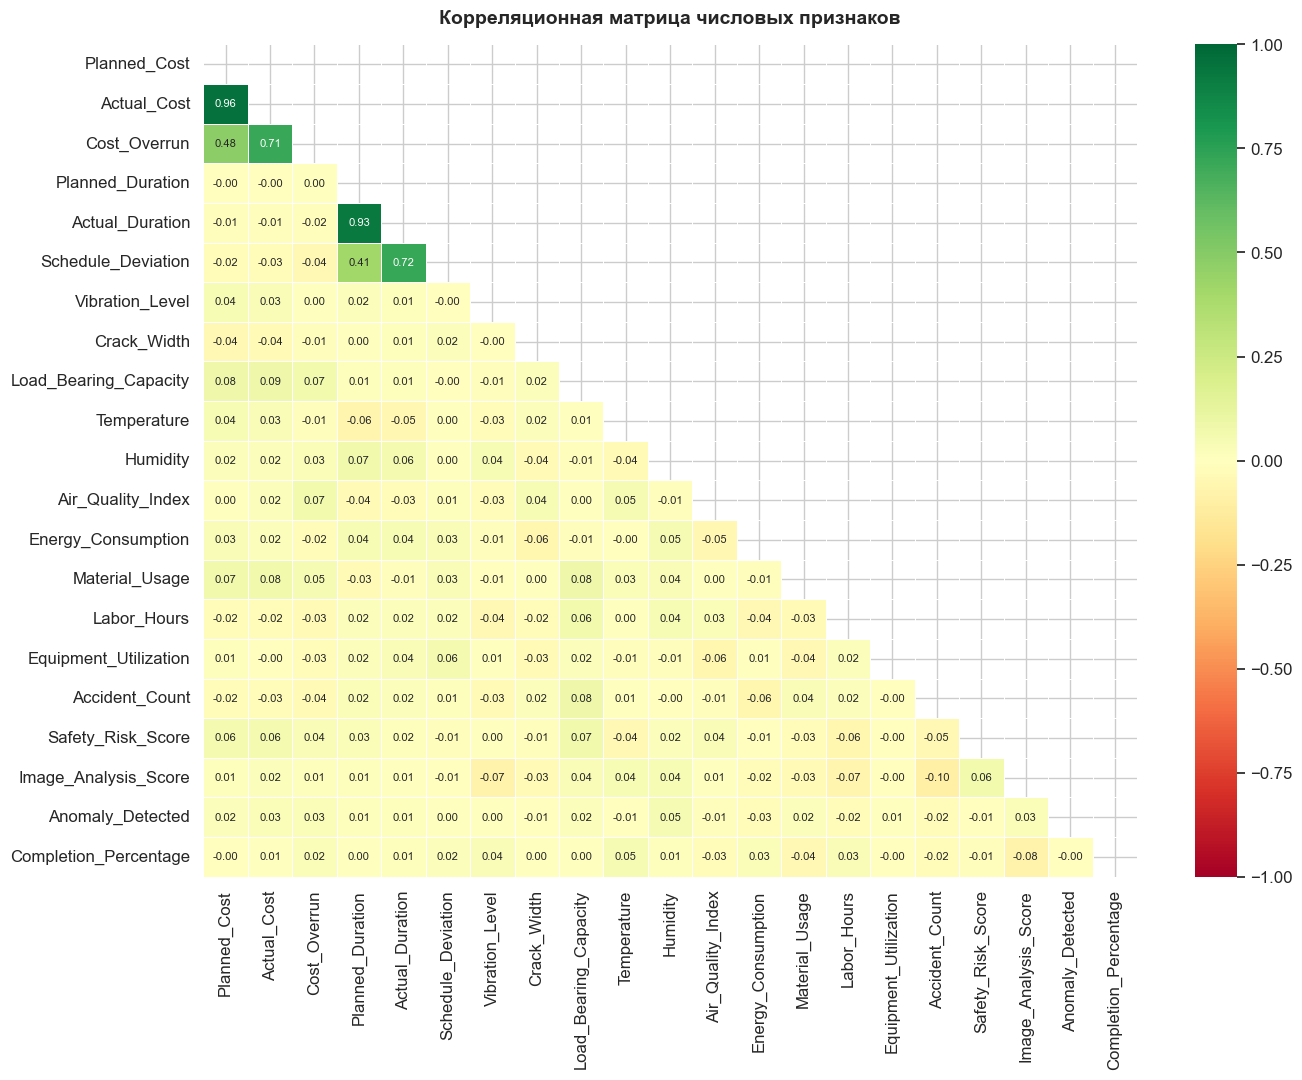

In [24]:
# Корреляционная матрица числовых признаков
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))  # скрываем верхний треугольник

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Корреляционная матрица числовых признаков',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Топ корреляций с Safety_Risk_Score и Cost_Overrun
for target_col in ['Safety_Risk_Score', 'Cost_Overrun']:
    top_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False).head(7)
    print(f'\nТоп-7 корреляций с {target_col}:')
    for feat, val in top_corr.items():
        direction = '(+)' if corr[target_col][feat] > 0 else '(-)'
        print(f'   {feat:30s}: {val:.3f} {direction}')


Топ-7 корреляций с Safety_Risk_Score:
   Load_Bearing_Capacity         : 0.074 (+)
   Image_Analysis_Score          : 0.064 (+)
   Actual_Cost                   : 0.059 (+)
   Planned_Cost                  : 0.057 (+)
   Labor_Hours                   : 0.056 (-)
   Accident_Count                : 0.045 (-)
   Temperature                   : 0.042 (-)

Топ-7 корреляций с Cost_Overrun:
   Actual_Cost                   : 0.712 (+)
   Planned_Cost                  : 0.480 (+)
   Load_Bearing_Capacity         : 0.067 (+)
   Air_Quality_Index             : 0.067 (+)
   Material_Usage                : 0.054 (+)
   Schedule_Deviation            : 0.040 (-)
   Safety_Risk_Score             : 0.038 (+)


## 7. Анализ дат и временных признаков <a id='7'></a>

In [26]:
# Создаём временные признаки для анализа
df['Project_Duration_Days'] = (df['End_Date'] - df['Start_Date']).dt.days
df['Start_Year']  = df['Start_Date'].dt.year
df['Start_Month'] = df['Start_Date'].dt.month

print('Временной диапазон датасета:')
print(f'   Начало: {df["Start_Date"].min().date()}')
print(f'   Конец : {df["End_Date"].max().date()}')
print(f'   Лет охвата: {(df["End_Date"].max() - df["Start_Date"].min()).days // 365}')

Временной диапазон датасета:
   Начало: 2020-01-01
   Конец : 2025-02-20
   Лет охвата: 5


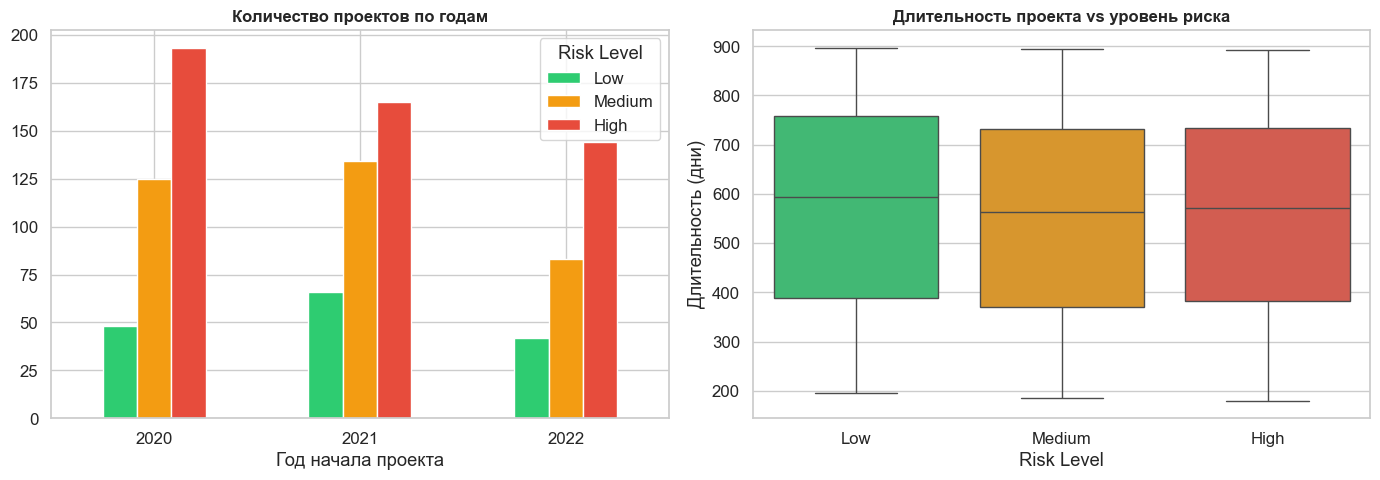

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Количество проектов по годам
year_counts = df.groupby(['Start_Year', 'Risk_Level']).size().unstack(fill_value=0)
year_counts = year_counts.reindex(columns=RISK_ORDER)
year_counts.plot(kind='bar', ax=axes[0],
                 color=[RISK_COLORS[r] for r in RISK_ORDER],
                 edgecolor='white')
axes[0].set_title('Количество проектов по годам', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Год начала проекта')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Risk Level')

# Длительность проекта vs Risk_Level
sns.boxplot(data=df, x='Risk_Level', y='Project_Duration_Days',
            order=RISK_ORDER, palette=RISK_COLORS, ax=axes[1])
axes[1].set_title('Длительность проекта vs уровень риска', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Длительность (дни)')

plt.tight_layout()
plt.savefig('../reports/06_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Выводы <a id='8'></a>

In [28]:
print('=' * 60)
print('ВЫВОДЫ EDA')
print('=' * 60)

print(f'''
1. ДАТАСЕТ
   • {df.shape[0]} строк, {df.shape[1]} признаков
   • Пропущенных значений: нет
   • Тип задачи: мультиклассовая классификация (3 класса)

2. ЦЕЛЕВАЯ ПЕРЕМЕННАЯ (Risk_Level)
   • High   : {(df.Risk_Level=='High').sum()} ({(df.Risk_Level=='High').mean()*100:.1f}%) — доминирующий класс
   • Medium : {(df.Risk_Level=='Medium').sum()} ({(df.Risk_Level=='Medium').mean()*100:.1f}%)
   • Low    : {(df.Risk_Level=='Low').sum()} ({(df.Risk_Level=='Low').mean()*100:.1f}%) — недопредставлен
   → Применить fix_imbalance=True в PyCaret

3. ВАЖНЫЕ ПРИЗНАКИ (для модели)
   • Cost_Overrun и Schedule_Deviation — прямые индикаторы риска
   • Safety_Risk_Score — сильная связь с Risk_Level
   • Accident_Count — коррелирует с высоким риском
   • Completion_Percentage — низкий % = высокий риск

4. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ
   • Project_Type: все типы (Bridge, Dam, Tunnel, Building, Road)
     равномерно распределены по классам риска
   • Location: аналогично — нет сильной привязки к риску
   • Weather_Condition: влияет на риск
   • Anomaly_Detected: сильный предиктор высокого риска

5. ЧТО УДАЛИТЬ ПЕРЕД ОБУЧЕНИЕМ
   • Project_ID — идентификатор, не несёт информации
   • Start_Date, End_Date — заменим на числовые признаки

6. НОВЫЕ ПРИЗНАКИ ДЛЯ ETL
   • Project_Duration_Days = End_Date - Start_Date
   • Duration_Overrun = Actual_Duration - Planned_Duration (= Schedule_Deviation)
   • Cost_Overrun_Pct = Cost_Overrun / Planned_Cost * 100
   • Start_Year, Start_Month
''')
print('=' * 60)
print('EDA завершён. Следующий шаг: 02_ETL.ipynb')

ВЫВОДЫ EDA

1. ДАТАСЕТ
   • 1000 строк, 31 признаков
   • Пропущенных значений: нет
   • Тип задачи: мультиклассовая классификация (3 класса)

2. ЦЕЛЕВАЯ ПЕРЕМЕННАЯ (Risk_Level)
   • High   : 502 (50.2%) — доминирующий класс
   • Medium : 342 (34.2%)
   • Low    : 156 (15.6%) — недопредставлен
   → Применить fix_imbalance=True в PyCaret

3. ВАЖНЫЕ ПРИЗНАКИ (для модели)
   • Cost_Overrun и Schedule_Deviation — прямые индикаторы риска
   • Safety_Risk_Score — сильная связь с Risk_Level
   • Accident_Count — коррелирует с высоким риском
   • Completion_Percentage — низкий % = высокий риск

4. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ
   • Project_Type: все типы (Bridge, Dam, Tunnel, Building, Road)
     равномерно распределены по классам риска
   • Location: аналогично — нет сильной привязки к риску
   • Weather_Condition: влияет на риск
   • Anomaly_Detected: сильный предиктор высокого риска

5. ЧТО УДАЛИТЬ ПЕРЕД ОБУЧЕНИЕМ
   • Project_ID — идентификатор, не несёт информации
   • Start_Date, End_Date — за